In [1]:
# Moja pierwsza komórka
print("Witaj w Jupyter Notebook!")
2 + 2

Witaj w Jupyter Notebook!


4

In [3]:
a = 5
b = 3


print("Dodawanie:", a + b)
print("Odejmowanie:", a - b)
print("Mnożenie:", a * b)
print("Dzielenie:", a / b)


print("Liczby od 1 do 5:")
for i in range(1, 6):
    print(i, end=" ")

Dodawanie: 8
Odejmowanie: 2
Mnożenie: 15
Dzielenie: 1.6666666666666667
Liczby od 1 do 5:
1 2 3 4 5 

# Laboratorium 2 — Eksploracja danych
**Autor:** [Natalia]  
**Data:** [22.03.26]

## Cel
Wczytanie i eksploracja datasetu z danymi z restauracji.

## Krok 1: Import bibliotek

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Krok 2: Wczytanie danych
Dataset: rachunki z restauracji (244 obserwacje, 7 zmiennych)


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
print(f"Dane wczytane: {df.shape[0]} wierszy, {df.shape[1]} kolumn")

Dane wczytane: 244 wierszy, 7 kolumn


## Krok 3: Poznanie danych

In [3]:
# Pierwsze 5 wierszy
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Ostatnie 5 wierszy
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
# Informacje o typach danych i brakujących wartościach
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [6]:
# Statystyki opisowe
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
# Typy danych w każdej kolumnie
df.dtypes

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

In [8]:
# Nazwy kolumn
df.columns.tolist()

['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

## Wnioski z eksploracji

- Dataset zawiera 244 wiersze i 7 kolumn
- Kolumny numeryczne: `total_bill`, `tip`, `size`
- Kolumny tekstowe (kategoryczne): `sex`, `smoker`, `day`, `time`
- Brakujące wartości: brak
- Średni rachunek (`total_bill`) ≈ 19.79 $

## Pytania biznesowe

In [14]:
# Pytanie 1: Najwyższy rachunek
najwyzszy_rachunek = df['total_bill'].max()
print(f"Najwyższy rachunek: ${najwyzszy_rachunek:.2f}")

Najwyższy rachunek: $50.81


In [15]:
# Pytanie 2: Ile rachunków w każdym dniu tygodnia
rachunki_dzien = df['day'].value_counts()
print("Rachunki wg dnia:")
print(rachunki_dzien.to_string())

Rachunki wg dnia:
day
Sat     87
Sun     76
Thur    62
Fri     19


In [16]:
# Pytanie 3: Średni napiwek dla palących vs niepalących
sredni_napiwek = df.groupby('smoker')['tip'].mean().round(2)
print("Średni napiwek (palący vs niepalący):")
for status, tip in sredni_napiwek.items():
    print(f"{status}: ${tip}")

Średni napiwek (palący vs niepalący):
No: $2.99
Yes: $3.01


In [17]:
# Pytanie 4: Średni procent napiwku
df['tip_percent'] = df['tip'] / df['total_bill'] * 100
sredni_proc_napiwku = df['tip_percent'].mean()
print(f"Średni procent napiwku: {sredni_proc_napiwku:.1f}%")

Średni procent napiwku: 16.1%


In [18]:
# Pytanie 5: Dzień + pora → średni rachunek
grupa = df.groupby(['day', 'time'])['total_bill'].mean().round(2)
najwyzsze_rachunki = grupa.sort_values(ascending=False).head(1)
print("Dzień + pora z najwyższymi rachunkami:")
print(najwyzsze_rachunki.to_string())

Dzień + pora z najwyższymi rachunkami:
day  time  
Sun  Dinner    21.41


## Wizualizacja

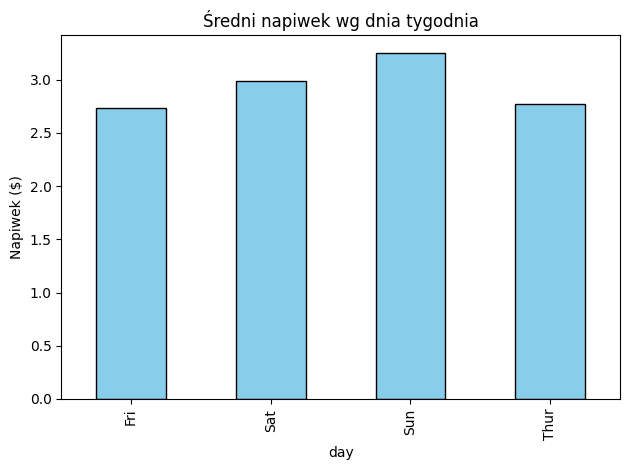

In [19]:
# Średni napiwek wg dnia tygodnia
df.groupby('day')['tip'].mean().plot(
    kind='bar', 
    title='Średni napiwek wg dnia tygodnia',
    color='skyblue',
    edgecolor='black'
)
plt.ylabel('Napiwek ($)')
plt.tight_layout()
plt.show()

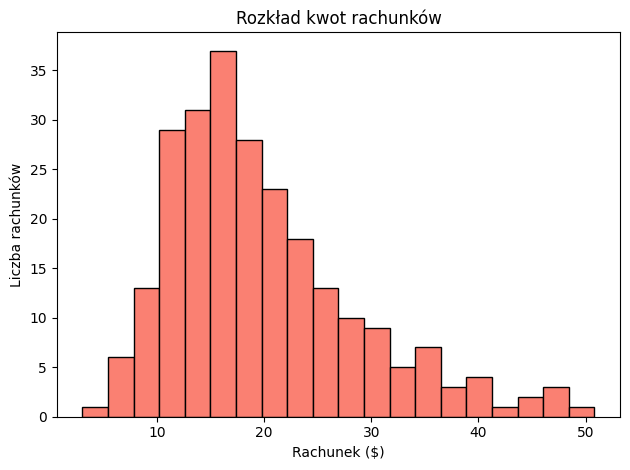

In [20]:
# Rozkład rachunków — histogram
df['total_bill'].plot(
    kind='hist', 
    bins=20, 
    title='Rozkład kwot rachunków', 
    edgecolor='black', 
    color='salmon'
)
plt.xlabel('Rachunek ($)')
plt.ylabel('Liczba rachunków')
plt.tight_layout()
plt.show()